# receptor ligand analysis 
# (1) using squidpy implementation of cellphonedb

In [2]:
import squidpy as sq
import scanpy as sc

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
bdata = adata[adata.obs['compartment'].str.contains('orsal')]
bdata

replicates = {}
for rep in bdata.obs.batch_key.unique():
    replicates[rep] = bdata[bdata.obs.batch_key == rep].copy()

In [3]:
example_rep = replicates['D7IMQ_F3']

In [4]:
res = sq.gr.ligrec(
    example_rep,
    n_perms=1000,
    cluster_key="celltype_assignments",
    copy=True,
    use_raw=False,
    transmitter_params={"categories": "ligand"},
    receiver_params={"categories": "receptor"},
)

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 1000/1000 [01:22<00:00, 12.12permutation/s]


In [10]:
res["pvalues"].head()

cluster_1     M2-like_macrophage                                          \
cluster_2     M2-like_macrophage activated_basal_KC activated_corneocyte   
source target                                                              
EPOR   TRPC3                 NaN                NaN                  NaN   
FYN    TRPC4                 NaN                NaN                  NaN   
       TRPC6                 NaN                NaN                  NaN   
       TRPV4               0.074                NaN                  NaN   
KL     TRPV5                 NaN                NaN                  NaN   

cluster_1                                                                   \
cluster_2     activated_intermediate_basal_suprabasal_KC activated_spinous   
source target                                                                
EPOR   TRPC3                                         NaN               NaN   
FYN    TRPC4                                         NaN               NaN   
       TRPC6                                         NaN               NaN   
       TRPV4                                       0.445             0.011   
KL     TRPV5                                         NaN               NaN   

cluster_1                                                            \
cluster_2     activated_suprabasal_KC adipocyte basal_KC corneocyte   
source target                                                         
EPOR   TRPC3                      NaN       NaN      NaN        NaN   
FYN    TRPC4                      NaN       NaN      NaN        NaN   
       TRPC6                      NaN       NaN      NaN        NaN   
       TRPV4                    0.398       NaN      NaN        NaN   
KL     TRPV5                      NaN       NaN      NaN        NaN   

cluster_1                        ...                    suprabasal_KC  \
cluster_2     dermal_fibroblast  ... intermediate_basal_suprabasal_KC   
source target                    ...                                    
EPOR   TRPC3                NaN  ...                              NaN   
FYN    TRPC4                NaN  ...                              NaN   
       TRPC6                NaN  ...                              NaN   
       TRPV4                NaN  ...                              NaN   
KL     TRPV5                NaN  ...                              NaN   

cluster_1                                                                \
cluster_2     late_activated_suprabasal_KC mast_cell myeloid neutrophil   
source target                                                             
EPOR   TRPC3                           NaN       NaN     NaN        NaN   
FYN    TRPC4                           NaN       NaN     NaN        NaN   
       TRPC6                           NaN       NaN     NaN        NaN   
       TRPV4                           NaN       NaN     NaN        NaN   
KL     TRPV5                           NaN       NaN     NaN        NaN   

cluster_1                                                                     \
cluster_2     perichondral_fibroblast schwann_cell sebaceous_epithelial  smc   
source target                                                                  
EPOR   TRPC3                      NaN          NaN                  NaN  NaN   
FYN    TRPC4                      NaN          NaN                  NaN  NaN   
       TRPC6                      NaN          NaN                  NaN  NaN   
       TRPV4                      NaN          NaN                  NaN  NaN   
KL     TRPV5                      NaN          NaN                  NaN  NaN   

cluster_1                    
cluster_2     suprabasal_KC  
source target                
EPOR   TRPC3            NaN  
FYN    TRPC4            NaN  
       TRPC6            NaN  
       TRPV4            NaN  
KL     TRPV5            NaN  

[5 rows x 484 columns]

In [11]:
res["metadata"].head()

aspect_intercell_source aspect_intercell_target  \
source target                                                   
EPOR   TRPC3               functional              functional   
FYN    TRPC4               functional              functional   
       TRPC6               functional              functional   
       TRPV4               functional              functional   
KL     TRPV5               functional              functional   

              category_intercell_source category_intercell_target  \
source target                                                       
EPOR   TRPC3                     ligand                  receptor   
FYN    TRPC4                     ligand                  receptor   
       TRPC6                     ligand                  receptor   
       TRPV4                     ligand                  receptor   
KL     TRPV5                     ligand                  receptor   

              category_source_intercell_source  \
source target                                    
EPOR   TRPC3                 resource_specific   
FYN    TRPC4                 resource_specific   
       TRPC6                 resource_specific   
       TRPV4                 resource_specific   
KL     TRPV5                 resource_specific   

              category_source_intercell_target  consensus_direction  \
source target                                                         
EPOR   TRPC3                 resource_specific                 True   
FYN    TRPC4                         composite                False   
       TRPC6                         composite                 True   
       TRPV4                 resource_specific                 True   
KL     TRPV5                         composite                 True   

               consensus_inhibition  consensus_score_intercell_source  \
source target                                                           
EPOR   TRPC3                  False                                 1   
FYN    TRPC4                  False                                 2   
       TRPC6                  False                                 2   
       TRPV4                  False                                 2   
KL     TRPV5                  False                                 3   

               consensus_score_intercell_target  ...  scope_intercell_source  \
source target                                    ...                           
EPOR   TRPC3                                  3  ...                 generic   
FYN    TRPC4                                  1  ...                 generic   
       TRPC6                                  1  ...                 generic   
       TRPV4                                  3  ...                 generic   
KL     TRPV5                                  1  ...                 generic   

               scope_intercell_target secreted_intercell_source  \
source target                                                     
EPOR   TRPC3                  generic                      True   
FYN    TRPC4                  generic                     False   
       TRPC6                  generic                     False   
       TRPV4                  generic                     False   
KL     TRPV5                  generic                      True   

              secreted_intercell_target  \
source target                             
EPOR   TRPC3                      False   
FYN    TRPC4                      False   
       TRPC6                      False   
       TRPV4                      False   
KL     TRPV5                      False   

                                              sources  \
source target                                           
EPOR   TRPC3                                     TRIP   
FYN    TRPC4                               TRIP;dbPTM   
       TRPC6   SPIKE_LC;HPRD;PhosphoPoint;TRIP;SIGNOR   
       TRPV4          SPIKE_LC;HPRD;PhosphoPoint;TRIP   
KL     TRPV5                          

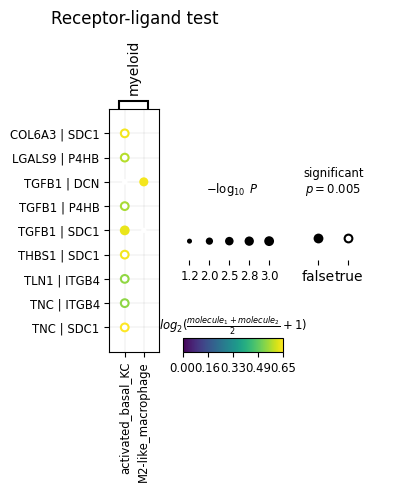

In [24]:
import matplotlib.pyplot as plt

sq.pl.ligrec(res, 
             source_groups = ["myeloid"], 
             target_groups = ['basal_KC', 'activated_basal_KC', 'M2-like_macrophage'], 
             remove_empty_interactions=True,
             remove_nonsig_interactions=True,
             means_range = (0.45,0.8),
             pvalue_threshold = 0.005,
             alpha=0.005,
             )


In [16]:
adata.layers

Layers with keys: counts, normalised

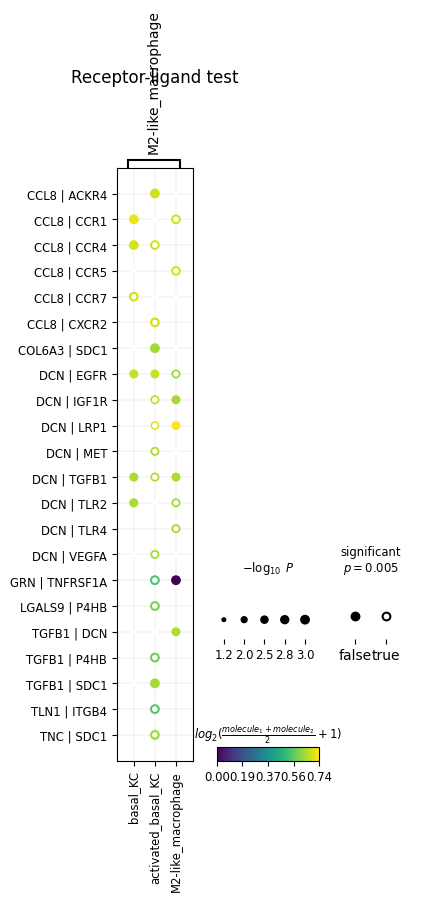

In [25]:
sq.pl.ligrec(res, 
             source_groups = ["M2-like_macrophage"], 
             target_groups = ['basal_KC', 'activated_basal_KC', 'M2-like_macrophage'], 
             remove_empty_interactions=True,
             remove_nonsig_interactions=True,
             means_range = (0.45,0.8),
             pvalue_threshold = 0.005,
             alpha=0.005,
             )

# ligand-receptor analysis using LARIS

In [ ]:
#install Laris
#redo analysis with Laris, as spatial context may be better preserved and we can map it back onto domains etc
#also do morphology mapping

In [11]:
import scanpy as sc
import laris as la

adata = sc.read_h5ad(r"D:\Dom\Psoriasis project\4th year data\Second Round Data\Xenium outputs - second round\Resegmented Xenium Outputs\ResolVI_subclusters.h5ad")
bdata = adata[adata.obs['compartment'].str.contains('orsal')]
bdata

replicates = {}
for rep in bdata.obs.batch_key.unique():
    replicates[rep] = bdata[bdata.obs.batch_key == rep].copy()

d:\Dom\Virtual_Environments\napari_registration_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [7]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
sc.set_figure_params(dpi=96,dpi_save=300, color_map='viridis',facecolor='white')
plt.rcParams['figure.figsize'] = 4, 4
sc.settings.verbosity = 3
sc.logging.print_header()

C:\Users\dbuxton\AppData\Local\Temp\ipykernel_1760\145925768.py:4: RuntimeWarning: Failed to import dependencies for application/vnd.jupyter.widget-view+json representation. (ModuleNotFoundError: No module named 'ipywidgets')
  sc.logging.print_header()


Package,Version
scanpy,1.11.5
anndata,0.12.6
numpy,2.2.6
pandas,2.3.3
matplotlib,3.10.7
Component,Info
Python,"3.13.13 (tags/v3.13.13:01104ce, Apr 7 2026, 19:25:48) [MSC v.1944 64 bit (AMD64)]"
OS,Windows-11-10.0.26100-SP0
CPU,"14 logical CPU cores, Intel64 Family 6 Model 170 Stepping 4, GenuineIntel"
GPU,No GPU found


In [5]:
import liana
from liana.resource import select_resource

#liana.resource.show_resources() use if you want to see other dfs available

# Get CellChatDB mouse interactions
lr_df = select_resource('mouseconsensus') #obtaining a mouse lig-rec dataframe
lr_df.head(2)

,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2


In [ ]:
from pathlib import Path
results_path = Path()

unfiltered_dfs = {}
interesting_dfs = {}

# looping over replicates
for name, adata in replicates.items():
    #filtering lig/recs not present in adata
    rows_keep = np.logical_and(lr_df['ligand'].isin(adata.var_names), lr_df['receptor'].isin(adata.var_names))
    lr_df_filtered = lr_df.loc[rows_keep].copy()

    #creating the ligand receptor anndata object for LARIS
    lr_adata = la.tl.prepareLRInteraction(
        adata,
        lr_df_filtered,
        number_nearest_neighbors = 15,
        use_rep_spatial = 'X_spatial'
    )

    #run LARIS
    warnings.filterwarnings("ignore")
    LARIS_variable_interactions, res_LARIS=la.tl.runLARIS(
        lr_df_filtered,
        adata,
        use_rep='X_spatial',
        n_nearest_neighbors=15,
        random_seed=27,
        n_repeats=5,
        mu = 1, # larger value indicates more consideration for specificity
        sigma=100,#controls how quickly spatial weights decay with distance
        remove_lowly_expressed=True,
        expressed_pct=0.1,
        n_cells_expressed_threshold=100,
        n_top_lr=lr_adata.shape[1],

        by_celltype=True,
        ### Parameters for cell type-level inference when by_celltype set to True
        groupby='celltype_assignments', # label to group by
        use_rep_spatial='X_spatial', # spatial coordinates
        mu_celltype=100, # higher value puts more emphasis on cell type specificity
        expressed_pct_celltype=0.1, # expression percentage cut off per cell type
        remove_lowly_expressed_celltype=True,
        mask_threshold=1e-6, # mask for cosg, lower value is less restrictive
        n_neighbors_permutation=30,
        score_threshold= 1e-10,
        spatial_weight = 3.0,
    )

    #############################################################################
    #saving results
    LARIS_variable_interactions_path = results_path / (name + "variable_Ints.csv")
    LARIS_variable_interactions.to_csv(LARIS_variable_interactions_path)

    res_LARIS_path = results_path / (name + "celltype_Res.csv")
    res_LARIS.to_csv(res_LARIS_path)

    unfiltered_dfs[name] = [LARIS_variable_interactions, res_LARIS]
    #############################################################################

    immune_cells = ['myeloid', 'M2-like_macrophage']
    KCs = ['activated_basal_KC', 'basal_KC']

    for A in immune_cells:
        for B in KCs:
            immune_skin = res_LARIS[(res_LARIS['sender'] == 'a') & (res_LARIS['receiver'] == 'b')
                    & (res_LARIS['p_value'] <0.05)]
            
            skin_immune = res_LARIS[(res_LARIS['sender'] == 'b') & (res_LARIS['receiver'] == 'a')
                    & (res_LARIS['p_value'] <0.05)]
            
            interesting_dfs[name] = [immune_skin, skin_immune]